# 🛒 Data Visualization Exercise — Sessions 11 & 12
### Domain: E-Commerce Order Analytics
---

## 📌 About This Notebook

This is a **guided exercise notebook**. You will work through a real-life e-commerce dataset and answer business questions by writing Python code and interpreting charts.

The notebook is structured in **four sections**:

| Section | Focus | Skills Covered |
|---------|-------|----------------|
| A | Data Exploration | `read_csv`, `info`, `describe`, `isnull`, `head` |
| B | Session 11 Charts | Histogram, Scatter, Bar, Pie, Count Plot, Box Plot, Regression Plot |
| C | Feature Engineering + Session 12 Charts | `pd.cut`, `np.log`, Violin, Swarm, Pivot Heatmap, Pairplot, Correlation Heatmap |
| D | Business Interpretation | Written insight questions |

---

## 📂 Dataset: `ecommerce_orders_exercise.csv`

This dataset contains **60 real-style e-commerce orders** placed on an Indian online retail platform.

| Column | Type | Description |
|--------|------|-------------|
| `Order_ID` | Text | Unique order identifier |
| `Customer_Name` | Text | Name of the customer |
| `City` | Text | City from which order was placed |
| `Customer_Segment` | Categorical | Consumer / Corporate / Home Office |
| `Product_Category` | Categorical | Electronics / Clothing / Furniture / Food / Books |
| `Order_Month` | Text | Month in which order was placed |
| `Delivery_Days` | Numeric | Number of days taken to deliver |
| `Order_Value` | Numeric (INR) | Total value of the order |
| `Discount_Percent` | Numeric (%) | Discount applied on the order |
| `Profit` | Numeric (INR) | Profit earned on the order |
| `Customer_Rating` | Numeric (1–5) | Rating given by the customer post delivery |
| `Payment_Mode` | Categorical | Credit Card / UPI / COD / Debit Card / Net Banking |
| `Returned` | Binary | Whether the order was returned (Yes / No) |

---

## 📝 Instructions
- Run cells **top to bottom** — each section builds on the previous one.
- Replace every `# ✏️ YOUR CODE HERE` comment with your own code.
- Read all comments carefully — they explain **why** each step matters, not just what to type.
- For interpretation questions, type your answer in the **markdown cell** that says *Your Answer Here*.
- Do NOT skip the Setup cell — all later cells depend on it.

---
# ⚙️ Section A — Setup & Data Exploration

## 🔧 Task A1 — Import Libraries & Load Data

**Business Context:**  
Before any analysis can begin, a business analyst must set up their working environment. Think of this like opening Excel, installing the add-ins, and importing the data file — except in Python, we do it in three lines.

**Your Task:**  
1. Import `pandas`, `numpy`, `matplotlib.pyplot`, and `seaborn`.
2. Set the seaborn style to `"whitegrid"`.
3. Load the file `ecommerce_orders_exercise.csv` into a DataFrame called `df`.
4. Display the first 5 rows.

> 💡 **Hint:** Use `pd.read_csv("filename.csv")` to load the data.

In [3]:
# ============================================================
# TASK A1: SETTING UP THE ENVIRONMENT
# ============================================================
# These four libraries are the standard toolkit for data analysis in Python.
# You will use them in almost every project you work on professionally.

# pandas  → loads CSVs, lets you filter rows/columns, compute group averages, etc.
# numpy   → fast mathematical operations — we'll use it for the log transformation later
# matplotlib → the low-level drawing engine that produces all chart types
# seaborn → a beautiful layer on top of matplotlib — professional charts with less code

# ✏️ YOUR CODE HERE — import the four libraries with their standard aliases
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 


# ✏️ YOUR CODE HERE — set seaborn style to "whitegrid"
# (This adds subtle horizontal grid lines that make charts easier to read in presentations)
sns.set_theme(style="whitegrid")



# ✏️ YOUR CODE HERE — load "ecommerce_orders_exercise.csv" into a variable called df
df=pd.read_csv("ecommerce_orders_exercise.csv")


# ✏️ YOUR CODE HERE — display the first 5 rows to verify the data loaded correctly
print(df.head())

  Order_ID Customer_Name       City Customer_Segment Product_Category  \
0     O001  Aarav Sharma     Mumbai         Consumer      Electronics   
1     O002   Priya Mehta      Delhi        Corporate         Clothing   
2     O003   Rohan Verma  Bangalore      Home Office        Furniture   
3     O004   Sneha Patel  Ahmedabad         Consumer            Books   
4     O005   Karan Singh     Mumbai         Consumer      Electronics   

  Order_Month  Delivery_Days  Order_Value  Discount_Percent  Profit  \
0     January              3        12500                 5    1800   
1     January              5         3200                10     420   
2    February              7        18900                 0    3100   
3    February              2          850                15      95   
4    February              4        22000                 8    2600   

   Customer_Rating Payment_Mode Returned  
0                4  Credit Card       No  
1                3          UPI       No  
2    

## 🔍 Task A2 — Data Quality Check

**Business Context:**  
Before drawing any charts or making any decisions, a good analyst audits the data. This is equivalent to checking whether all cells in your Excel sheet are filled in and whether the column types are correct.

**Your Task:**  
1. Run `df.info()` — understand the column names, data types, and whether any column has missing values.
2. Run `df.describe()` — get a statistical snapshot of every numeric column.
3. Check how many values are missing per column using `.isnull().sum()`.
4. Check if any rows are exact duplicates using `.duplicated().sum()`.

> 💡 **Hint:** These are four separate method calls. Run them one after another in the same cell.

In [ ]:
# ============================================================
# TASK A2: DATA QUALITY / AUDIT
# ============================================================

# STEP 1: df.info()
# This tells you:
#   - How many rows and columns exist
#   - The name and data type (dtype) of each column
#   - How many non-null (non-missing) values each column has
# KEY INSIGHT: If Order_Value shows dtype 'object' instead of 'int64' or 'float64',
# it means the column was read as text — all your averages and charts will break silently!

# ✏️ YOUR CODE HERE
df.info()


# STEP 2: df.describe()
# This gives a 5-number summary (mean, std, min, 25%, 50%, 75%, max) for every numeric column.
# Compare the min and max of Order_Value — the range tells you whether the data is spread out
# (wide range = likely outliers) or concentrated (narrow range = homogeneous customers).

# ✏️ YOUR CODE HERE
df.describe()


# STEP 3: Missing value check — .isnull().sum()
# isnull() returns True wherever a cell is empty, .sum() counts those Trues per column.
# Even one null in a key column (e.g., Order_Value) will cause chart errors later.

# ✏️ YOUR CODE HERE
print("check null",df.isnull().sum())


# STEP 4: Duplicate row check — .duplicated().sum()
# Duplicates are dangerous: if Order O007 appears twice, all averages for Electronics
# get inflated because that high-value order is counted twice.

# ✏️ YOUR CODE HERE
df.duplicated().sum()

np.int64(0)

---
# 📊 Section B — Session 11: Core Visualization Charts

## 📊 Task B1 — Histogram: How are Order Values distributed?

**Business Context:**  
The Sales Head wants to understand the spread of order values. Are most orders small (below ₹5,000) or are they evenly spread? Are there very large orders that are outliers? A **histogram** answers these questions by showing how many orders fall in each price band.

**Your Task:**  
Plot a histogram of the `Order_Value` column with **15 bins**. Add a title, x-label, and y-label.

> 💡 **Hint:** Use `plt.hist(df["column_name"], bins=__)`. Then add `plt.title()`, `plt.xlabel()`, `plt.ylabel()`, and `plt.show()`.

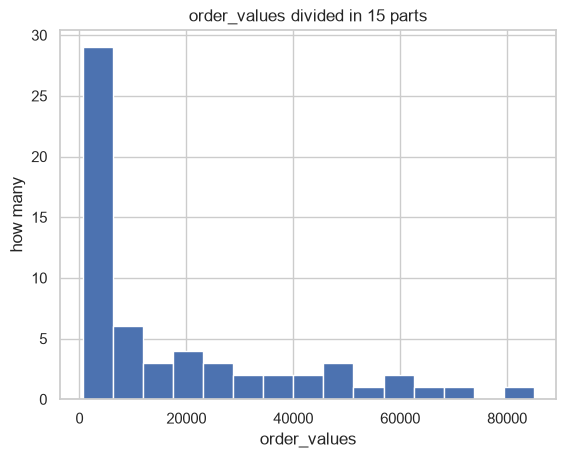

In [65]:
# ============================================================
# TASK B1: HISTOGRAM — Distribution of Order Values
# ============================================================
# A histogram divides the entire range of Order_Value into equal-width 'bins'
# and counts how many orders fall into each bin.
#
# bins=15 means we cut the range (₹650 to ₹85,000) into 15 equal slices.
# Fewer bins → fewer, broader bars (too generalized).
# More bins  → many narrow bars (too granular, noisy).
# 10–20 is usually the sweet spot for 50–100 row datasets.
#
# WHAT TO LOOK FOR in the output:
#   - Is the distribution RIGHT-SKEWED? (most orders are cheap, a few are very expensive)
#   - Is there a clear peak? Where is it?
#   - Are there isolated bars far to the right? Those are likely high-value B2B orders.

# ✏️ YOUR CODE HERE — draw the histogram with 15 bins
plt.hist(df["Order_Value"],bins=15)


# ✏️ YOUR CODE HERE — add a descriptive title (make it business-friendly)
plt.title("order_values divided in 15 parts")

# ✏️ YOUR CODE HERE — label the x-axis (what does each value on x represent?)
plt.xlabel("order_values")

# ✏️ YOUR CODE HERE — label the y-axis (what does the height of each bar represent?)
plt.ylabel("how many")

# ✏️ YOUR CODE HERE — render and show the chart
plt.show()

## 📊 Task B2 — Scatter Plot: Does higher Discount eat into Profit?

**Business Context:**  
The Finance team suspects that aggressive discounting hurts profitability. They want a visual to present to the board. A **scatter plot** places each order as a dot — discount on the x-axis, profit on the y-axis — and lets you spot the relationship at a glance.

**Your Task:**  
Plot a scatter plot with `Discount_Percent` on the x-axis and `Profit` on the y-axis.

> 💡 **Hint:** Use `plt.scatter(df["x_column"], df["y_column"])`.

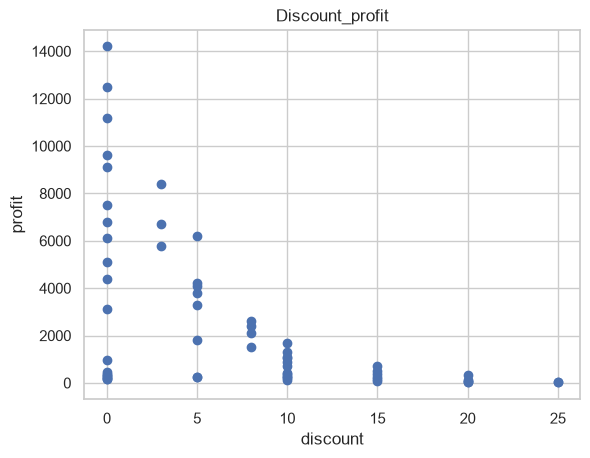

In [66]:
# ============================================================
# TASK B2: SCATTER PLOT — Discount vs Profit
# ============================================================
# Each dot in a scatter plot represents ONE order.
# Its horizontal position = how much discount was given.
# Its vertical position  = how much profit was earned.
#
# Patterns to watch for:
#   NEGATIVE slope (dots go down-right): discounts reduce profit — confirms the fear.
#   FLAT cloud (no pattern):             discount has no effect on profit in this dataset.
#   POSITIVE slope (dots go up-right):   unlikely but could mean discounts drive volume.
#
# Remember: scatter plots reveal CORRELATION, not causation.
# Even a strong downward trend doesn't prove discounts CAUSE low profit —
# but it IS a strong enough signal to investigate further.

# ✏️ YOUR CODE HERE — draw the scatter plot (Discount_Percent on x, Profit on y)
plt.scatter(df["Discount_Percent"],df["Profit"])

# ✏️ YOUR CODE HERE — add a business-friendly title
plt.title("Discount_profit")


# ✏️ YOUR CODE HERE — label both axes
plt.xlabel("discount")
plt.ylabel("profit")

# ✏️ YOUR CODE HERE — show the chart
plt.show()

## 📊 Task B3 — Bar Chart: Which Product Category generates the highest average Profit?

**Business Context:**  
The Category Management team wants to know where to focus marketing spend. A **bar chart** of average profit per category lets them compare performance at a glance.

**Your Task:**  
1. Group the data by `Product_Category` and compute the mean of `Profit`.
2. Plot a bar chart of the result.
3. Add title, axis labels, and rotate the x-axis tick labels by 30 degrees.

> 💡 **Hint:** Use `df.groupby("category_col")["numeric_col"].mean()` then `.plot(kind="bar")`.

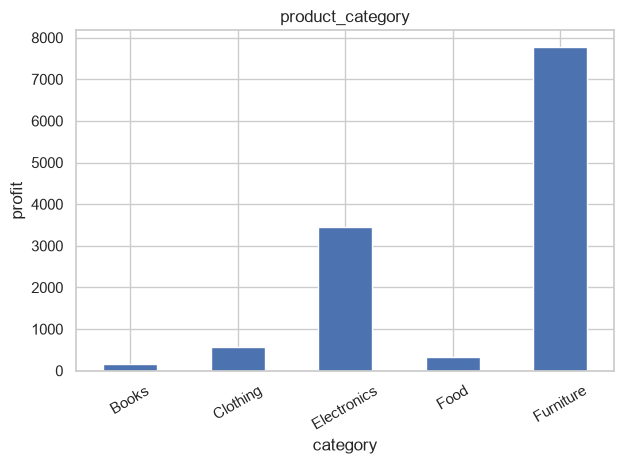

In [64]:
# ============================================================
# TASK B3: BAR CHART — Average Profit by Product Category
# ============================================================
# groupby + mean is the Python equivalent of a PivotTable in Excel:
#   - groupby("Product_Category") → splits the dataset by category
#   - ["Profit"].mean()           → computes the average profit within each group
#
# The result is a pandas Series where the index = category name, value = avg profit.
# Calling .plot(kind="bar") on a Series produces a bar chart automatically.
#
# plt.xticks(rotation=30) tilts the category labels so they don't overlap.
# Use plt.tight_layout() at the end to prevent labels from being cut off.

# STEP 1: Compute average profit per category
# ✏️ YOUR CODE HERE
df.groupby("Product_Category")["Profit"].mean().plot(kind="bar")

# STEP 2: Plot as a bar chart
# ✏️ YOUR CODE HERE

# STEP 3: Add title and axis labels
# ✏️ YOUR CODE HERE
plt.title("product_category")
plt.xlabel("category")
plt.ylabel("profit")


# STEP 4: Rotate x-axis labels and tighten layout
plt.xticks(rotation=30)
plt.tight_layout()

# ✏️ YOUR CODE HERE — show the chart

## 🥧 Task B4 — Pie Chart: What share of orders does each Customer Segment represent?

**Business Context:**  
The marketing team wants to understand the customer mix. Are most orders coming from individual consumers, corporate buyers, or home offices? A **pie chart** shows proportional composition at a glance.

**Your Task:**  
1. Count the number of orders per `Customer_Segment`.
2. Plot a pie chart showing the percentage share of each segment.
3. Use `autopct="%1.1f%%"` to display percentages on the pie slices.

> 💡 **Hint:** Use `df["Customer_Segment"].value_counts()` to get the counts, then `plt.pie(counts, labels=counts.index, autopct=...)`.

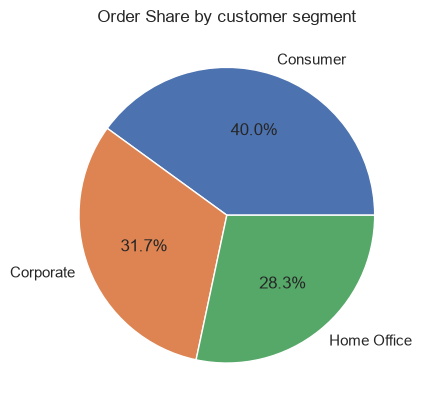

In [33]:
# ============================================================
# TASK B4: PIE CHART — Order Share by Customer Segment
# ============================================================
# value_counts() counts how many rows belong to each unique category.
# For a pie chart, the slice AREAS represent proportions — so the input must be counts,
# not averages or sums.
#
# autopct="%1.1f%%"  → %1.1f means 'show one decimal place', followed by a % sign.
#                       This prints the percentage on top of each slice automatically.
#
# Limitation of pie charts: they work well with 3–5 categories.
# More than 6 slices makes the chart hard to read — use a bar chart instead.

# STEP 1: Get order counts per segment
# ✏️ YOUR CODE HERE
counts=df["Customer_Segment"].value_counts()


# STEP 2: Plot the pie chart
# ✏️ YOUR CODE HERE
plt.pie(counts,labels=counts.index,autopct="%1.1f%%")


# STEP 3: Add a title
# ✏️ YOUR CODE HERE
plt.title("Order Share by customer segment")

# ✏️ YOUR CODE HERE — show the chart
plt.show()

## 📊 Task B5 — Count Plot: Which Payment Mode is used most often?

**Business Context:**  
The Payments team wants to know how customers prefer to pay. Knowing this helps them decide where to invest in payment infrastructure (e.g., should they expand UPI partnerships?).

**Your Task:**  
Use seaborn's `countplot` to show the count of orders for each `Payment_Mode`.

> 💡 **Hint:** `sns.countplot(x="column_name", data=df)`. Add `plt.xticks(rotation=20)` to avoid label overlap.

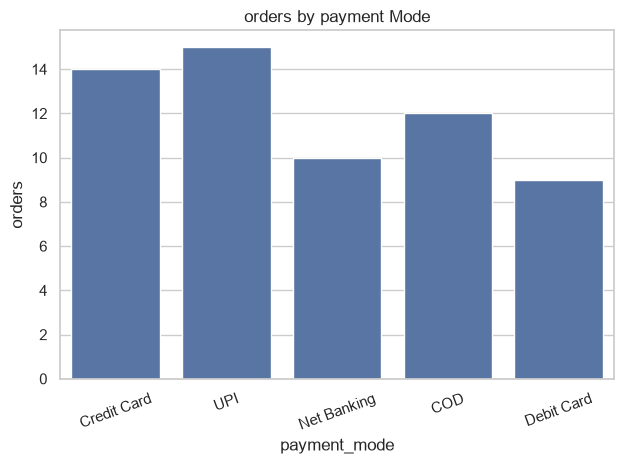

In [35]:
# ============================================================
# TASK B5: COUNT PLOT — Orders by Payment Mode
# ============================================================
# countplot is seaborn's version of a bar chart for COUNTING category frequencies.
# It automatically counts how many rows belong to each category —
# you don't need to run value_counts() yourself.
#
# Difference vs pie chart:
#   Pie  → good for showing PROPORTIONS (% of whole)
#   Bar/Count → better for showing ABSOLUTE COUNTS and COMPARISONS between categories
#
# When categories have long names (e.g., 'Net Banking', 'Debit Card'),
# always rotate x-axis labels to prevent them from overlapping.

# ✏️ YOUR CODE HERE — draw the count plot
sns.countplot(x="Payment_Mode",data=df)

# ✏️ YOUR CODE HERE — add title and axis labels
plt.title("orders by payment Mode")
plt.xlabel("payment_mode")
plt.ylabel("orders")


plt.xticks(rotation=20)
plt.tight_layout()

# ✏️ YOUR CODE HERE — show the chart

## 📦 Task B6 — Box Plot: Are there outlier orders in Order Value?

**Business Context:**  
Before computing averages or building pricing models, analysts check for outliers. A **box plot** summarises the distribution using five numbers and flags any extreme values as dots outside the whiskers.

**Your Task:**  
Draw a box plot for `Order_Value`. Add a title and x-axis label.

> 💡 **Hint:** Use `sns.boxplot(x=df["Order_Value"])`. The box shows the middle 50% of values (IQR). Dots outside the whiskers are statistical outliers.

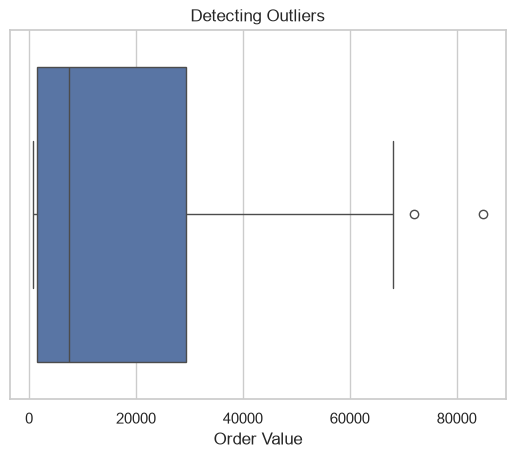

In [37]:
# ============================================================
# TASK B6: BOX PLOT — Detecting Outliers in Order Value
# ============================================================
# A box plot packs five statistics into one chart:
#   ─ Left whisker  : minimum (after removing outliers)
#   ─ Left edge of box  : 25th percentile (Q1) — 25% of orders are below this value
#   ─ Vertical line in box : Median (Q2) — 50% above, 50% below
#   ─ Right edge of box : 75th percentile (Q3)
#   ─ Right whisker : maximum (after removing outliers)
#   ○ Dots beyond the whiskers : OUTLIERS — orders far outside the normal range
#
# WHY THIS MATTERS:
#   If the median Order_Value is ₹8,000 but the mean is ₹20,000, it means a few
#   large Furniture/Electronics orders are pulling the average up.
#   Always check the box plot BEFORE reporting averages to leadership.

# ✏️ YOUR CODE HERE — draw the box plot
sns.boxplot(x=df["Order_Value"])

# ✏️ YOUR CODE HERE — add title and x-axis label
plt.title("Detecting Outliers")
plt.xlabel("Order Value")


# ✏️ YOUR CODE HERE — show the chart
plt.show()

## 📉 Task B7 — Regression Plot: Does higher Order Value lead to higher Profit?

**Business Context:**  
The CFO wants to know whether larger orders also tend to be more profitable, or whether big orders sometimes come with big costs. A **regression plot** draws the data points AND fits a trend line with a shaded confidence band simultaneously.

**Your Task:**  
Use `sns.regplot` to plot `Order_Value` (x) vs `Profit` (y).

> 💡 **Hint:** `sns.regplot(x="col1", y="col2", data=df)`. The shaded band around the line is the 95% confidence interval — the narrower it is, the stronger the relationship.

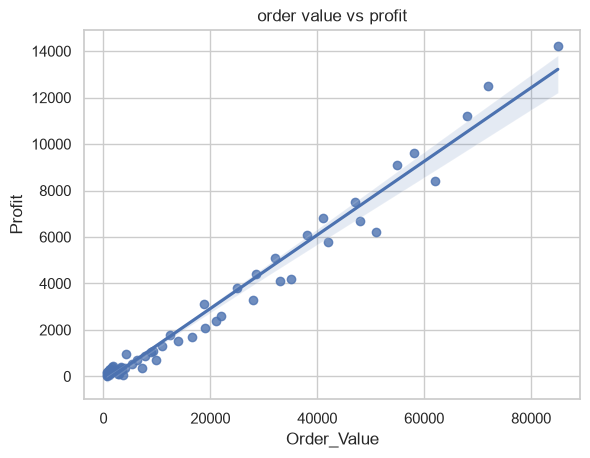

In [39]:
# ============================================================
# TASK B7: REGRESSION PLOT — Order Value vs Profit
# ============================================================
# sns.regplot does THREE things in one call:
#   1. Draws a scatter plot of all individual order points
#   2. Fits a LEAST SQUARES regression line through the cloud
#   3. Shades a 95% CONFIDENCE BAND around that line
#
# How to read the output:
#   STEEP upward slope   → strong positive relationship (bigger orders = more profit)
#   FLAT slope            → order value doesn't predict profit well
#   WIDE confidence band  → high uncertainty — we need more data to be sure
#   NARROW confidence band → the relationship is consistent and reliable
#
# This is different from a simple scatter: the trend line gives you a PREDICTIVE
# direction — it's the first step toward understanding if a formal regression model
# (which you'll learn in ML sessions) would be worth building.

# ✏️ YOUR CODE HERE — draw the regression plot
sns.regplot(x="Order_Value", y="Profit", data=df)

# ✏️ YOUR CODE HERE — add title and axis labels
plt.title("order value vs profit")
plt.xlabel("Order_Value")
plt.ylabel("Profit")


# ✏️ YOUR CODE HERE — show the chart
plt.show()

---
# 🔬 Section C — Feature Engineering + Session 12 Charts

## 🔧 Task C1 — Feature Engineering: Create 3 New Variables

**Business Context:**  
Raw data often needs to be transformed into more meaningful business-level variables before charting. This is called **feature engineering**. Think of it as creating calculated columns in Excel.

**Your Task — Create these 3 new columns in `df`:**

1. **`Value_Tier`** — Segment orders into value tiers using `pd.cut()`:  
   - Low: ₹0 – ₹5,000  
   - Medium: ₹5,000 – ₹25,000  
   - High: ₹25,000 – ₹90,000  

2. **`Log_Order_Value`** — Log transform of `Order_Value` using `np.log()`.  
   *(Reduces right skewness caused by a few very large Furniture/Electronics orders.)*

3. **`Profit_Margin`** — Compute `Profit / Order_Value * 100` (profit as a % of order value).

> 💡 **Hint for pd.cut:** `pd.cut(df["col"], bins=[0, 5000, 25000, 90000], labels=["Low", "Medium", "High"])`

In [41]:
# ============================================================
# TASK C1: FEATURE ENGINEERING — 3 New Business Columns
# ============================================================

# ── VARIABLE 1: Value_Tier ────────────────────────────────────
# pd.cut() converts a continuous numeric column into discrete LABELLED CATEGORIES.
# This is identical to Excel's nested IF formula:
#   =IF(A2<=5000,"Low", IF(A2<=25000,"Medium", "High"))
# But in one readable line of Python.
#
# WHY do we need bins?
# An order worth ₹12,500 and one worth ₹13,000 are operationally the same tier.
# Binning removes noise and lets us compare 'Medium vs High' rather than exact rupee values.
#
# IMPORTANT: bins must cover the full range of Order_Value.
# Always check df["Order_Value"].min() and .max() before setting bins.

# ✏️ YOUR CODE HERE — create df["Value_Tier"] using pd.cut()
df["Value_Tier"] = pd.cut(
    df["Order_Value"],
    bins=[0, 5000, 25000, float("inf")],
    labels=["Low", "Medium", "High"]
)



# ── VARIABLE 2: Log_Order_Value ───────────────────────────────
# np.log() computes the natural logarithm (base e) of each value.
# WHY? Because order values are RIGHT-SKEWED:
#   Most orders cluster between ₹650–₹15,000, but a few Furniture/Electronics orders
#   go up to ₹85,000. These outliers stretch the x-axis and hide patterns in charts.
#   The log COMPRESSES large values, bringing them closer to the rest of the data.
#   A ₹10,000 order becomes log(10,000) ≈ 9.2 and ₹85,000 becomes log(85,000) ≈ 11.3
#   — the difference is now 2.1 instead of 75,000.

# ✏️ YOUR CODE HERE — create df["Log_Order_Value"] using np.log()

df["Log_Order_Value"] = np.log(df["Order_Value"])


# ── VARIABLE 3: Profit_Margin ─────────────────────────────────
# Profit_Margin = Profit earned as a PERCENTAGE of Order_Value.
# Formula: (Profit / Order_Value) * 100
#
# WHY is this better than raw Profit alone?
# A ₹14,200 profit on an ₹85,000 Furniture order = 16.7% margin.
# A ₹6,800 profit on a ₹41,000 Furniture order = 16.6% margin.
# Both are equally profitable — but looking at raw profit alone, the first looks 2× better.
# Margin normalises for deal size so you can compare fairly across categories.

# ✏️ YOUR CODE HERE — create df["Profit_Margin"]
df["Profit_Margin"] = (df["Profit"] / df["Order_Value"]) * 100


# Verify the new columns exist and look correct
df[["Order_ID", "Order_Value", "Profit", "Value_Tier", "Log_Order_Value", "Profit_Margin"]].head(8)

,Order_ID,Order_Value,Profit,Value_Tier,Log_Order_Value,Profit_Margin
0,O001,12500,1800,Medium,9.433484,14.400000
1,O002,3200,420,Low,8.070906,13.125000
2,O003,18900,3100,Medium,9.846917,16.402116
3,O004,850,95,Low,6.745236,11.176471
4,O005,22000,2600,Medium,9.998798,11.818182
5,O006,1200,310,Low,7.090077,25.833333
6,O007,35000,4200,High,10.463103,12.000000
7,O008,2800,120,Low,7.937375,4.285714


## 🎻 Task C2 — Violin Plot: How does Order Value vary by Customer Segment?

**Business Context:**  
The Sales Director wants to understand the distribution of order sizes for each customer segment — not just the average. A violin plot shows the full spread: median, spread, and whether the distribution is skewed, all in one chart.

**Your Task:**  
Draw a violin plot with `Customer_Segment` on the x-axis and `Order_Value` on the y-axis.

> 💡 **Hint:** `sns.violinplot(x="cat_col", y="num_col", data=df)`  
> The wider the violin at any height = more orders at that value. The white dot inside = median.

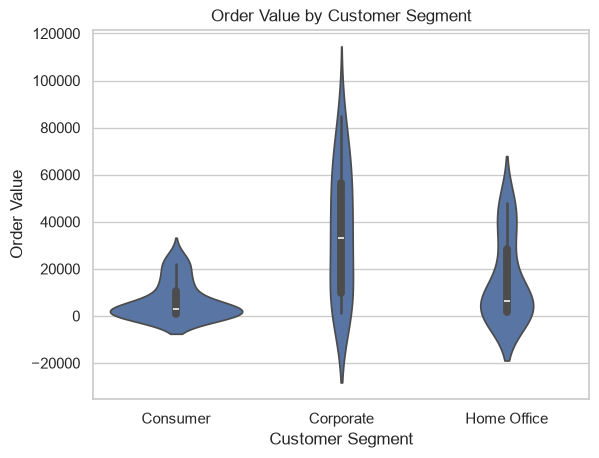

In [67]:
# ============================================================
# TASK C2: VIOLIN PLOT — Order Value by Customer Segment
# ============================================================
# A violin plot = box plot + density curve combined.
#
# How to read it:
#   ● The WHITE DOT in the centre  → median order value for that segment
#   ● The THICK BLACK BAR           → interquartile range (Q1 to Q3); middle 50% of orders
#   ● The THIN BLACK LINE (whisker) → rest of the range, excluding extreme outliers
#   ● The WIDTH OF THE VIOLIN shape → density / frequency (wider = more orders at that value)
#
# ADVANTAGE over a simple box plot:
#   A box plot only shows 5 numbers. A violin shows the FULL SHAPE of the distribution.
#   For example: if the Corporate violin is fat at the top (₹50,000+),
#   it means Corporate customers tend to place many large orders.
#
# BUSINESS INSIGHT TO LOOK FOR:
#   Which segment has the highest median order value?
#   Which segment has the widest spread? (That means order sizes are unpredictable.)

# ✏️ YOUR CODE HERE — draw the violin plot
sns.violinplot(x="Customer_Segment", y="Order_Value", data=df)

# ✏️ YOUR CODE HERE — add title and axis labels
plt.title("Order Value by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Order Value")



# ✏️ YOUR CODE HERE — show the chart
plt.show()

## 🐝 Task C3 — Swarm Plot: How is Profit distributed across Order Value Tiers?

**Business Context:**  
Sometimes you want to see every individual data point — not just the summary. A **swarm plot** places each order as a dot without overlap, making it easy to see clustering and gaps.

**Your Task:**  
Draw a swarm plot with `Value_Tier` on the x-axis and `Profit` on the y-axis.

> 💡 **Hint:** `sns.swarmplot(x="Value_Tier", y="Profit", data=df)`.  
> Note: the x-axis order should follow Low → Medium → High. Use `order=["Low", "Medium", "High"]`.

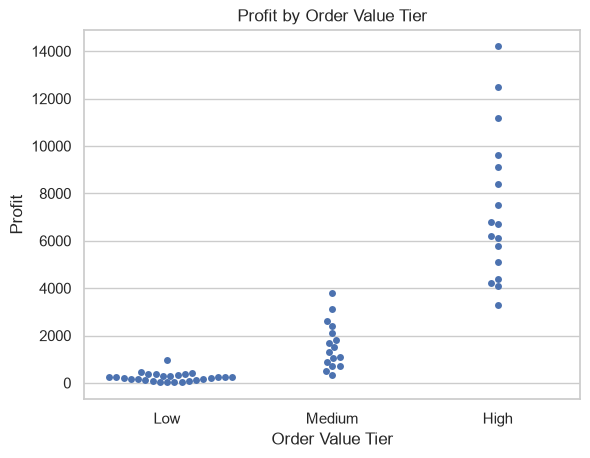

In [44]:
# ============================================================
# TASK C3: SWARM PLOT — Profit by Order Value Tier
# ============================================================
# A swarm plot places every single row as an individual dot.
# The algorithm automatically spreads the dots sideways so they don't overlap.
#
# WHY USE IT?
#   Box plots and violin plots summarise. Swarm plots show EVERYTHING.
#   You can see: outliers, clusters, gaps, and skewness simultaneously.
#   It's ideal for small datasets (< 200 rows) — for large data it gets too crowded.
#
# KEY PARAMETER: order=["Low", "Medium", "High"]
#   Because Value_Tier is a text column (not a number), seaborn may sort it
#   alphabetically (High, Low, Medium) unless you explicitly provide the desired order.
#   Always control the order of categorical axes to make charts easier to interpret.

# ✏️ YOUR CODE HERE — draw the swarm plot (use the order parameter)
sns.swarmplot(
    x="Value_Tier",
    y="Profit",
    data=df,
    order=["Low", "Medium", "High"]
)

# ✏️ YOUR CODE HERE — add title and axis labels

plt.title("Profit by Order Value Tier")
plt.xlabel("Order Value Tier")
plt.ylabel("Profit")

# ✏️ YOUR CODE HERE — show the chart
plt.show()

## 🗺️ Task C4 — Pivot Heatmap: Average Profit by Segment × Category

**Business Context:**  
The Strategy team wants a two-way view: which **combination** of Customer Segment and Product Category generates the highest average profit? A **pivot table heatmap** is the most powerful chart for answering this.

**Your Task:**  
1. Build a pivot table: rows = `Customer_Segment`, columns = `Product_Category`, values = mean of `Profit`.
2. Plot it as a heatmap using `annot=True`, `fmt=".0f"`, `cmap="YlOrRd"`.

> 💡 **Hint:** `pd.pivot_table(df, values="Profit", index="Customer_Segment", columns="Product_Category", aggfunc="mean")`

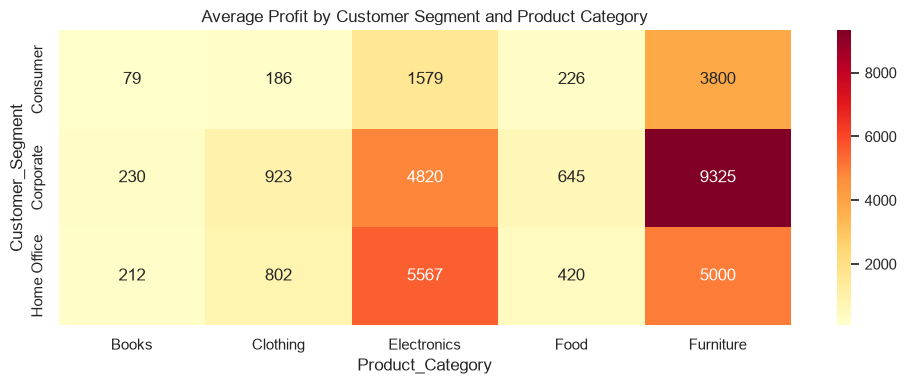

In [68]:
# ============================================================
# TASK C4: PIVOT TABLE HEATMAP — Avg Profit: Segment × Category
# ============================================================
# pd.pivot_table is Python's PivotTable (exactly like Excel's PivotTable):
#   - index    → the ROW dimension (Customer_Segment: Consumer/Corporate/Home Office)
#   - columns  → the COLUMN dimension (Product_Category: Electronics/Furniture/...)
#   - values   → what to aggregate (Profit)
#   - aggfunc  → HOW to aggregate (we want the average, so "mean")
#
# Then sns.heatmap() colours each cell by its value:
#   annot=True  → prints the actual number inside each cell
#   fmt=".0f"   → format as integer (no decimal places) — easier for rupee values
#   cmap="YlOrRd" → Yellow = low profit, Red = high profit (intuitive for business)
#
# plt.figure(figsize=(10,4)) before the heatmap makes it wide enough to read comfortably.
#
# BUSINESS INSIGHT TO FIND:
#   The darkest red cell is your most profitable Segment × Category combination.
#   That's where you should concentrate your marketing and inventory investment.

# STEP 1: Create the pivot table
# ✏️ YOUR CODE HERE
pivot=pd.pivot_table(df, values="Profit",index="Customer_Segment",columns="Product_Category",aggfunc="mean")


# STEP 2: Create figure and draw heatmap
plt.figure(figsize=(10, 4))
# ✏️ YOUR CODE HERE — sns.heatmap(...)
sns.heatmap(
    pivot,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd"
)

# ✏️ YOUR CODE HERE — add a descriptive title
plt.title("Average Profit by Customer Segment and Product Category")

plt.tight_layout()

# ✏️ YOUR CODE HERE — show the chart
plt.show()

## 🔗 Task C5 — Pairplot: Explore All Numeric Relationships at Once

**Business Context:**  
At the start of analysis, analysts do an **exploratory sweep** of all numeric variables to see which pairs show interesting relationships before spending time on detailed charts. The pairplot produces a grid of scatter plots and histograms in one go.

**Your Task:**  
Draw a pairplot of numeric columns using `hue="Value_Tier"` to colour the dots by tier.

> 💡 **Hint:** `sns.pairplot(df[["Order_Value", "Discount_Percent", "Profit", "Delivery_Days", "Customer_Rating", "Value_Tier"]], hue="Value_Tier")`

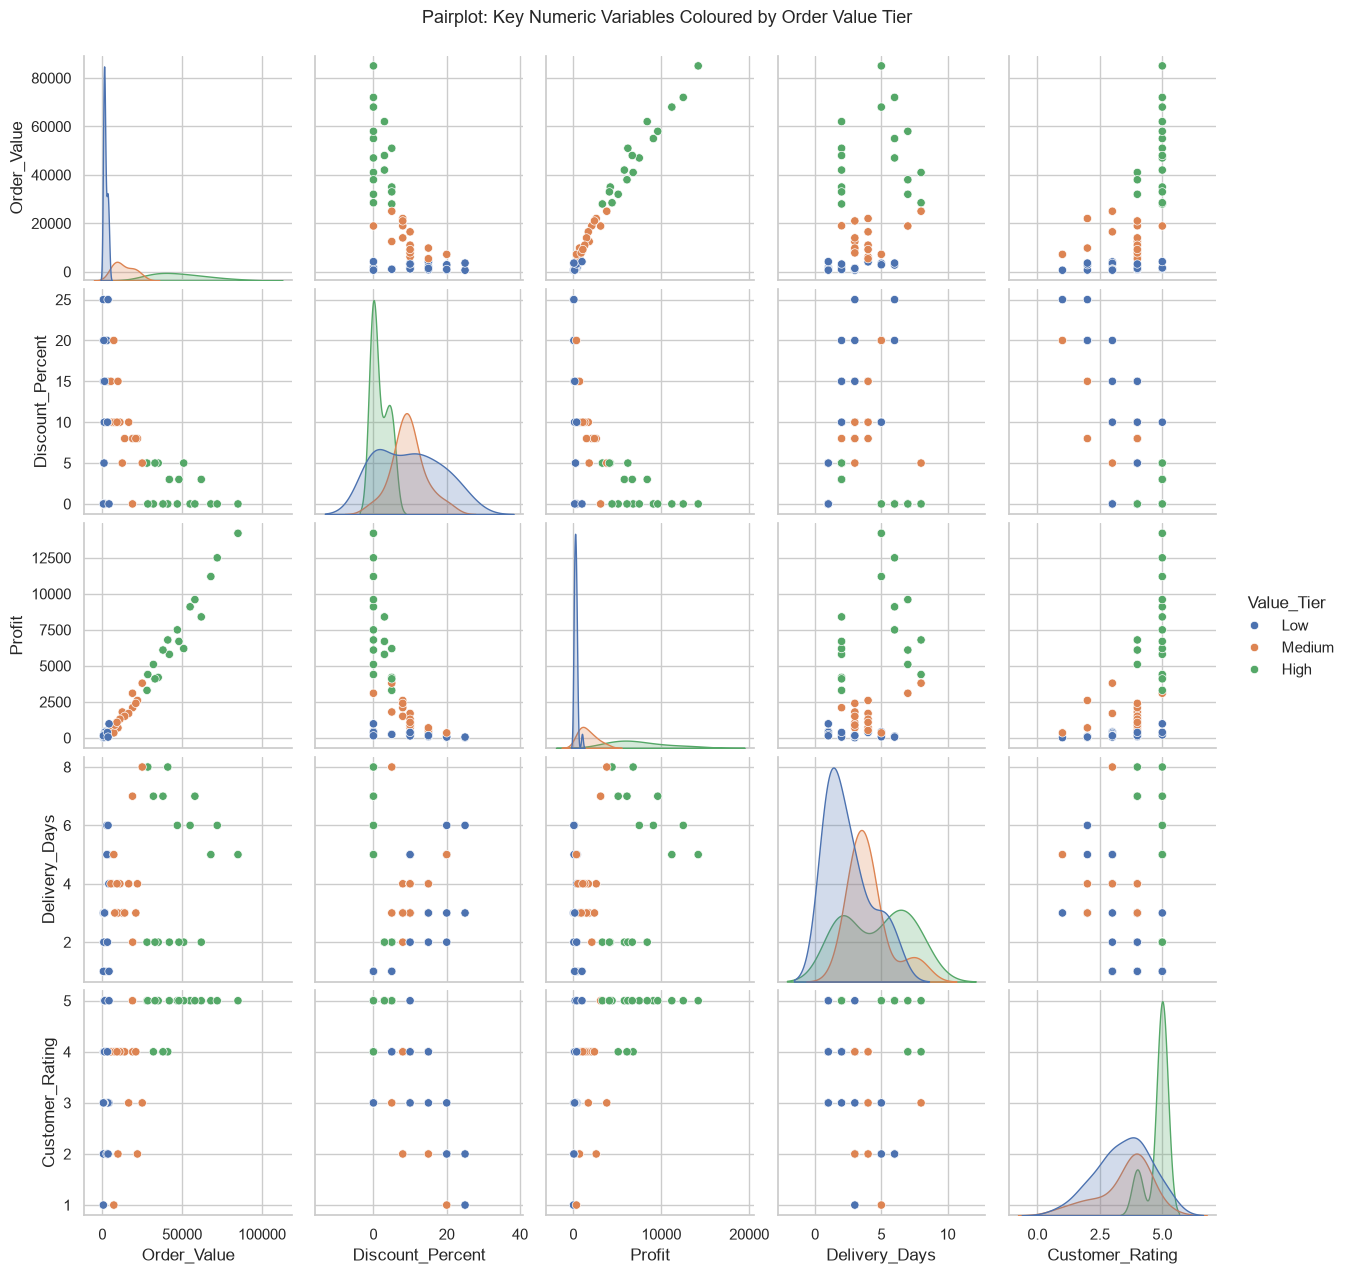

In [70]:
# ============================================================
# TASK C5: PAIRPLOT — All Numeric Relationships by Value Tier
# ============================================================
# sns.pairplot generates a GRID of charts:
#   - DIAGONAL cells     → histogram/KDE for each variable (distribution shape)
#   - OFF-DIAGONAL cells → scatter plot for every pair of variables
#
# hue="Value_Tier" colours each dot by whether the order is Low, Medium, or High value.
# This reveals if relationships DIFFER by tier:
#   e.g., do High-value orders cluster at high profits but low discounts?
#
# Variables to include: Order_Value, Discount_Percent, Profit, Delivery_Days,
#                       Customer_Rating, and Value_Tier (for hue)
#
# NOTE: You must pass a SUBSET of df with only the columns you want —
#       otherwise the pairplot will include Order_ID, Name, City etc. which are useless.
#
# plt.suptitle() adds an overall title above the entire grid.
# y=1.02 lifts it slightly above the top of the figure so it doesn't overlap.

# ✏️ YOUR CODE HERE — create the pairplot on the correct subset of columns
sns.pairplot(
    df[[
        "Order_Value",
        "Discount_Percent",
        "Profit",
        "Delivery_Days",
        "Customer_Rating",
        "Value_Tier"
    ]],
    hue="Value_Tier"
)

plt.suptitle("Pairplot: Key Numeric Variables Coloured by Order Value Tier", y=1.02, fontsize=13)

# ✏️ YOUR CODE HERE — show the chart
plt.show()

## 🌡️ Task C6 — Correlation Heatmap: Which variables are most strongly related?

**Business Context:**  
Before building any predictive model (e.g., predicting Profit from other variables), analysts need to understand which variables are correlated. A **correlation heatmap** shows the strength and direction of every pair-wise relationship in one chart.

**Your Task:**  
1. Select only numeric columns using `select_dtypes(include=[np.number])`.
2. Compute the correlation matrix with `.corr()`.
3. Plot the correlation heatmap with `annot=True`, `fmt=".2f"`, `cmap="coolwarm"`, `linewidths=0.5`.

> 💡 **Values range from -1 to +1:**  
> `+1` = perfect positive, `0` = no relationship, `-1` = perfect negative.

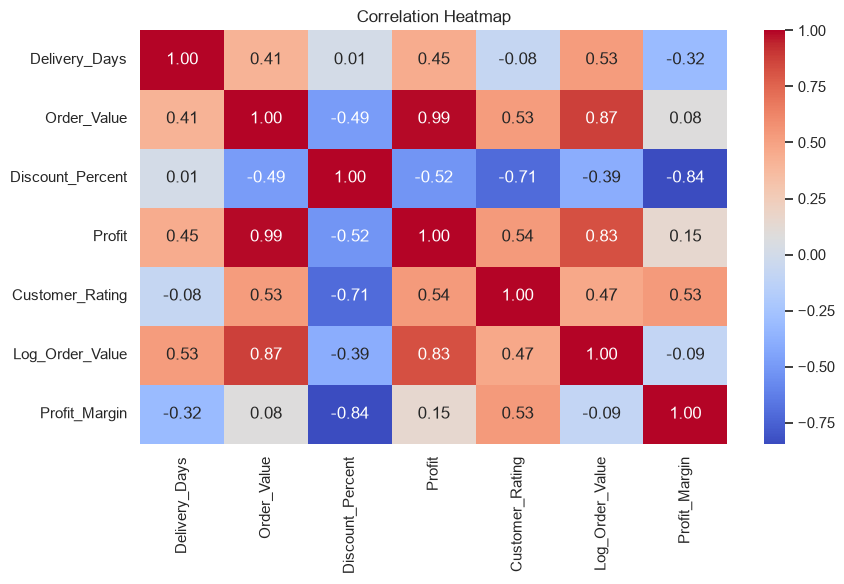

In [71]:
# ============================================================
# TASK C6: CORRELATION HEATMAP — Strength of All Relationships
# ============================================================
# Correlation coefficient (r) tells you:
#   r near +1 → strong positive relationship (as X goes up, Y goes up)
#   r near  0 → no linear relationship
#   r near -1 → strong negative relationship (as X goes up, Y goes down)
#
# CRITICAL RULE: .corr() only works on NUMERIC columns.
#   Text columns like Product_Category would cause a ValueError.
#   Always filter with .select_dtypes(include=[np.number]) FIRST.
#
# COLOUR MAP 'coolwarm':
#   Deep RED cells → strong positive correlation
#   Deep BLUE cells → strong negative correlation
#   WHITE/pale cells → near-zero correlation
#
# DIAGONAL cells are always 1.00 (every variable is perfectly correlated with itself).
# Ignore the diagonal; focus on the off-diagonal cells.
#
# plt.tight_layout() prevents axis labels from being clipped at the edges.

# STEP 1: Select only numeric columns
# ✏️ YOUR CODE HERE
numeric_df = df.select_dtypes(include=[np.number])

# STEP 2: Compute the correlation matrix
# ✏️ YOUR CODE HERE
corr_matrix = numeric_df.corr()

# STEP 3: Draw the heatmap
plt.figure(figsize=(9, 6))
# ✏️ YOUR CODE HERE — sns.heatmap(...)
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

# ✏️ YOUR CODE HERE — title
plt.title("Correlation Heatmap")

plt.tight_layout()

# ✏️ YOUR CODE HERE — show the chart
plt.show()

---
# 💡 Section D — Business Interpretation Questions

Answer each question **in the markdown cell below it** by typing your response where it says *Your Answer Here*. Base your answers on the charts you produced above.

### D1. Looking at your Histogram (Task B1):
Describe the shape of the Order Value distribution. Is it symmetric or skewed? Where is the majority of orders concentrated? What does this tell the Sales team about the typical customer?

**Your Answer Here:**  

The Order Value distribution is clearly right-skewed, with most orders clustering at the lower end of the range. We see a lot of smaller orders piling up on the left side, with the frequency dropping off as order values increase. This tells the Sales team that the majority of their customer base prefers to place smaller orders, which could indicate either budget constraints or a preference for frequent, smaller purchases rather than bulk buying. The long tail on the right side suggests there are occasional high-value orders, but these are exceptions rather than the norm. To grow revenue, the team might want to explore strategies for encouraging customers to consolidate purchases or increase order size through bundling or loyalty incentives.

### D2. Looking at your Scatter Plot (Task B2):
Does there appear to be a relationship between Discount_Percent and Profit? If you were presenting this to the CFO, what recommendation would you make about the company's discounting policy?

**Your Answer Here:**

There's a clear negative relationship between discount and profit - basically, the higher the discount we offer, the lower our profit margins become. You can see this really starkly in the chart: most of our best-performing orders (highest profits) are clustered at the 0-5% discount range, and as we go up to 15-20% discounts, profits drop significantly, sometimes even to nearly zero or negative. 

If I were presenting this to the CFO, I'd recommend being much more strategic about discounting. Right now it looks like we might be giving away margin without gaining enough additional volume to compensate. I'd suggest either cutting back on discounts altogether or using them more selectively - maybe limiting them to specific situations like clearance sales or high-volume deals where the volume justifies the margin loss. The data clearly shows that discounts are eroding profitability rather than driving it.

### D3. Looking at your Bar Chart (Task B3):
Which product category generates the highest average profit? Which generates the lowest? If you had to reallocate 20% of the marketing budget from the lowest category to the highest, how would you justify this decision using this chart?

**Your Answer Here:**

Looking at this chart, the difference in performance is pretty dramatic. Furniture clearly dominates with the highest average profit at around ₹7,700 per order, followed by Electronics at roughly ₹3,300. On the flip side, Books is our worst performer at just around ₹100 average profit, with Food and Clothing not much better at ₹300 and ₹500 respectively.

If I had to reallocate 20% of marketing budget from Books to Furniture, I'd justify it this way: Furniture is 77 times more profitable per order than Books. That's not a small difference - it's massive. Marketing spend should follow profit potential. By redirecting resources from our worst-performing category to our star performer, we'd likely see better ROI. Furniture clearly has market demand and healthy margins, so investing more in that category should give us a solid return. Meanwhile, Books is dragging down our overall profitability, and honestly, it might be worth questioning why we even stock it or if we need to completely rethink how we approach that category. The chart makes the case pretty clear.

### D4. Looking at your Violin Plot (Task C2):
Compare the three customer segments based on their violin shapes. Which segment is most consistent in order size (narrow violin)? Which is most variable? What operational implication does high variability in order size have for inventory planning?

**Your Answer Here:**

The three segments show pretty different patterns here. Consumer orders are clearly the most consistent - that narrow violin tells you that Consumer customers tend to order pretty predictably, all within a tight range. Corporate is the complete opposite - that massive violin is incredibly wide, showing that Corporate orders swing wildly from really small to massive. Home Office falls somewhere in between.

From an operations perspective, this variability in Corporate orders is actually a headache. When you can't predict order sizes, inventory planning becomes really difficult. With Consumers, you know roughly what to expect and can plan accordingly. But with Corporate, you're facing huge swings - sometimes a small order, sometimes a massive one. This means you either need to keep more inventory on hand (which ties up cash) or risk stockouts when a big order suddenly hits. The Home Office segment seems manageable by comparison. Honestly, this data suggests we should be looking at ways to stabilize Corporate orders, maybe through negotiated minimum orders or better demand forecasting, just to smooth out that chaos for the warehouse team.

### D5. Looking at your Pivot Heatmap (Task C4):
Identify the single most profitable Segment–Category combination (darkest cell). Then identify the least profitable combination (lightest cell). What strategic action could the company take based on this information?

**Your Answer Here:**

The heatmap really highlights where we're making money and where we're not. The darkest spot - the real winner - is Corporate + Furniture at ₹9,325 average profit. That's the golden combination. On the complete opposite end, the lightest spot is Consumer + Books at just ₹79, which is basically nothing.

The strategic implication here is pretty clear: we should be targeting Corporate buyers for Furniture. That's where the money is. Meanwhile, we need to seriously reconsider the Consumer + Books combination - either we rethink how we sell books to consumers, or we question whether books are even worth stocking for that segment. 

I'd recommend creating a special sales push for Corporate customers interested in Furniture - maybe bulk discounts, faster delivery, or dedicated account management. Meanwhile, either discontinue Books for Consumers or redesign how we present them (maybe in bundles with higher-margin items). The heatmap shows us exactly where to double down and where to cut our losses.

### D6. Looking at your Correlation Heatmap (Task C6):
Which two variables have the **strongest positive correlation**? Which pair has the **strongest negative correlation** (if any)? Does a high positive correlation between Order_Value and Profit confirm or contradict the regression plot from Task B7? Explain.

**Your Answer Here:**

Looking at the correlation matrix, it's crystal clear that Order_Value and Profit have the strongest positive relationship at 0.99 - that's basically a perfect positive correlation. That makes sense because higher order values naturally lead to higher profits.

On the negative side, the strongest negative correlation is between Discount_Percent and Profit_Margin at -0.84, which aligns with what we saw in that scatter plot earlier - giving discounts definitely hurts our margins.

As for whether the high positive correlation between Order_Value and Profit confirms the regression plot from Task B7, it absolutely does. The 0.99 correlation tells us mathematically what the scatter plot showed us visually - there's a rock-solid relationship between these two variables. When Order_Value goes up, Profit goes up consistently. That's why a simple linear regression using Order_Value to predict Profit makes so much sense and should give us a reliable model. The correlation coefficient essentially validates that this is worth modeling.

---
## ✅ Bonus Challenge — Optional Extension

If you finish early, attempt this unguided task:

**Business Question:** The Operations Head wants to understand whether orders that are **returned** (`Returned = Yes`) tend to have lower customer ratings. Build an appropriate chart to visually answer this question. Justify your choice of chart type.

In [ ]:
# ============================================================
# BONUS: Returned Orders vs Customer Rating
# ============================================================
# THINK BEFORE YOU CODE:
#   - 'Returned' is categorical (Yes/No) → it goes on the x-axis
#   - 'Customer_Rating' is numeric (1–5) → it goes on the y-axis
#   - You want to see the DISTRIBUTION of ratings within each group
#   - Which chart type from Sessions 11 & 12 handles one categorical + one numeric variable
#     and shows the full distribution shape? (Hint: Session 12 has two such options.)
#
# Write your chart code below. No hints this time — you've got this!

# ✏️ YOUR CODE HERE

**Justify your chart choice here:**  
*(Why did you pick this chart type? What does it show that a simple bar chart would miss?)*

---
# 🤖 Section E — Introduction to Machine Learning: Simple Linear Regression

This section introduces your **first Machine Learning model**.  

In Sections A–D you visualised relationships between variables — for example, you saw a scatter plot suggesting that higher `Order_Value` tends to produce higher `Profit`. **Simple Linear Regression (SLR) turns that visual observation into a mathematical equation** that can predict `Profit` for an entirely new, unseen order.

---

## 📐 The Equation You Are Building

$$\hat{Y} = \beta_0 + \beta_1 \cdot X$$

| Symbol | Meaning in this exercise |
|--------|--------------------------|
| $\hat{Y}$ | **Predicted Profit** (INR) — what the model outputs |
| $X$ | **Order_Value** (INR) — the single predictor we feed in |
| $\beta_0$ | **Intercept** — predicted profit when order value = ₹0 |
| $\beta_1$ | **Slope** — how much profit changes for every ₹1 increase in order value |

The algorithm finds $\beta_0$ and $\beta_1$ automatically by minimising prediction errors across all training orders.

---

## 🗺️ Section Roadmap

| Task | What you will do |
|------|-----------------|
| E1 | Import ML libraries from `sklearn` |
| E2 | Select X (predictor) and y (target), then perform Train-Test Split |
| E3 | Build and train the Linear Regression model |
| E4 | Visualise the fitted regression line |
| E5 | Evaluate with R², MAE, and RMSE |
| E6 | Actual vs Predicted plot |
| E7 | Residual analysis — check model assumptions |
| E8 | Make new business predictions |
| E9 | Written interpretation questions |

## 🔧 Task E1 — Import Machine Learning Libraries

**Business Context:**  
Until now you have used `pandas`, `numpy`, `matplotlib`, and `seaborn` — all already imported in Task A1. Machine Learning needs three additional tools from `scikit-learn` (`sklearn`):

1. **`train_test_split`** — splits data into a training set and a test set. The model learns *only* from the training set; the test set simulates brand-new, unseen orders.  
2. **`LinearRegression`** — the algorithm that finds the best-fit line through the data.  
3. **`mean_absolute_error`, `mean_squared_error`, `r2_score`** — metrics that tell us how accurate the model's predictions are.

**Your Task:** Import all three items from `sklearn`. The libraries `pandas`, `numpy`, `matplotlib`, and `seaborn` are already available from Section A.

In [ ]:
# ============================================================
# TASK E1: IMPORT SKLEARN MACHINE LEARNING TOOLS
# ============================================================
# These three imports give us everything needed to build, train, and evaluate
# a Simple Linear Regression model.

# train_test_split → divides our 60 orders into a training batch (model learns)
#                    and a test batch (model is evaluated without having seen these)
# ✏️ YOUR CODE HERE — import train_test_split from sklearn.model_selection


# LinearRegression → the algorithm itself; follows this simple 3-step workflow:
#   1. model = LinearRegression()        ← create an empty model
#   2. model.fit(X_train, y_train)       ← train it (finds β₀ and β₁)
#   3. model.predict(X_test)             ← generate predictions on new data
# ✏️ YOUR CODE HERE — import LinearRegression from sklearn.linear_model


# Evaluation metrics — each answers a different question about prediction accuracy:
#   mean_absolute_error → average gap between actual and predicted (in INR, easy to explain)
#   mean_squared_error  → same gap but large errors are penalised more heavily
#   r2_score            → what fraction of profit variation our model explains (0 = nothing, 1 = perfect)
# ✏️ YOUR CODE HERE — import mean_absolute_error, mean_squared_error, r2_score
#                     from sklearn.metrics


print("sklearn imports complete.")


## 📂 Task E2 — Select X and y, then Perform Train-Test Split

**Business Context:**  
We want to predict `Profit` from `Order_Value`. These two columns saw the strongest positive correlation in your heatmap (Task C6). The CFO's question: *"If a customer places a ₹3,000 order, how much profit should we expect?"*

**The Train-Test Split rule:**  
- **Training set (80%)** — the model learns the β₀ and β₁ relationship from these orders.  
- **Test set (20%)** — completely hidden during training. We use these to judge whether the model generalises to *new* orders it has never seen.  

> 💡 **Hint:** Use double brackets `df[["col_name"]]` for X (must be a 2D DataFrame, not a 1D Series) and single brackets `df["col_name"]` for y. For the split, use `test_size=0.2` and `random_state=42` (so everyone gets the same split).

In [ ]:
# ============================================================
# TASK E2: SELECT X, y AND PERFORM TRAIN-TEST SPLIT
# ============================================================

# --- Part A: Select the predictor (X) and target (y) ---
# X = Order_Value  → the single column we use to make predictions
# y = Profit       → the column we want to predict
#
# IMPORTANT: sklearn requires X to be 2D (a DataFrame, not just a Series).
# Use double brackets [["Order_Value"]] to ensure shape is (60, 1) not (60,).

# ✏️ YOUR CODE HERE — create X (2D DataFrame) and y (1D Series)
X =
y =

# Verify shapes — X should be (60, 1), y should be (60,)
print("Shape of X :", X.shape)
print("Shape of y :", y.shape)

# --- Part B: Train-Test Split ---
# test_size=0.2  → hold out 20% of 60 orders = 12 orders for testing
# random_state=42 → fixes the random shuffle for reproducibility

# ✏️ YOUR CODE HERE — split X and y using train_test_split
X_train, X_test, y_train, y_test =

print(f"\nTraining orders : {X_train.shape[0]}  ← model LEARNS β₀ and β₁ from these")
print(f"Test orders     : {X_test.shape[0]}  ← model is EVALUATED on these (never seen before)")


## 🏗️ Task E3 — Build and Train the Model

**Your Task:** Create a `LinearRegression` model, fit it on the training data, and then print the intercept and slope along with the full equation and their business interpretation.

> 💡 **Hints:**  
> - After `model.fit(...)`, the intercept is stored in `model.intercept_` and the slope in `model.coef_[0]`.  
> - `model.coef_` is an array (because MLR can have many predictors); we use `[0]` to pull out the first (and only) value for SLR.

In [ ]:
# ============================================================
# TASK E3: BUILD AND TRAIN THE LINEAR REGRESSION MODEL
# ============================================================
# sklearn's 3-step pattern (same for every algorithm):
#   Step 1 → create the model object (empty, no learning yet)
#   Step 2 → .fit() → find β₀ and β₁ from training data
#   Step 3 → .predict() → use the equation on new data (we do this in Task E5)

# Step 1: Create an untrained LinearRegression model object
# ✏️ YOUR CODE HERE
model =

# Step 2: Train the model — feed it X_train (order values) and y_train (profits)
# The algorithm solves the Ordinary Least Squares equations and stores the result.
# ✏️ YOUR CODE HERE
model.___(_______,  _______)

print("Model trained successfully.")

# Step 3: Extract the learned parameters
# intercept_ → β₀  (predicted profit when Order_Value = ₹0)
# coef_[0]   → β₁  (profit change per ₹1 increase in order value)
intercept = model.intercept_
slope     = model.coef_[0]

# Print the discovered equation
print(f"\nIntercept (β₀) : {intercept:.4f}")
print(f"Slope     (β₁) : {slope:.4f}")
print(f"\nFitted equation → Profit = {intercept:.2f}  +  {slope:.4f} × Order_Value")
print()
print(f"Business interpretation of β₁ = {slope:.4f}:")
print(f"  → Every ₹1 increase in order value is expected to add ₹{slope:.4f} to profit.")
print(f"Business interpretation of β₀ = {intercept:.2f}:")
print(f"  → Baseline profit when Order_Value approaches ₹0  (statistical baseline, not literal).")


## 📈 Task E4 — Visualise the Fitted Regression Line

**Your Task:** Draw a scatter plot of ALL 60 orders (Order_Value on X-axis, Profit on Y-axis) and overlay the model's best-fit line in a contrasting colour.

> 💡 **Hints:**  
> - To draw a *smooth* line (not just 60 joined dots), generate 300 evenly spaced X values with `np.linspace(df["Order_Value"].min(), df["Order_Value"].max(), 300).reshape(-1, 1)`, then call `model.predict()` on them.  
> - `reshape(-1, 1)` converts a 1D array to 2D — required by sklearn's `predict`.  
> - Annotate the chart with the equation using `ax.annotate()`.

In [ ]:
# ============================================================
# TASK E4: VISUALISE THE FITTED REGRESSION LINE
# ============================================================
# We draw two layers on top of each other:
#   Layer 1 → all 60 actual orders as scatter dots
#   Layer 2 → the model's best-fit line (computed from 300 smooth points)
#
# The vertical gap from each dot to the red line = that order's prediction error (residual).
# A tight cluster of dots around the line = the model fits well.

fig, ax = plt.subplots(figsize=(10, 6))

# --- Layer 1: Scatter of all 60 actual orders ---
# alpha=0.7 makes dots slightly transparent so overlapping ones are visible
# ✏️ YOUR CODE HERE — plot a scatter of df["Order_Value"] vs df["Profit"]


# --- Layer 2: Best-fit regression line ---
# Generate 300 evenly-spaced order values spanning the data range
x_line = np.linspace(df["Order_Value"].min(), df["Order_Value"].max(), 300).reshape(-1, 1)
# reshape(-1, 1) is required: sklearn's predict() expects a 2D array, not a 1D list.

# Compute the predicted profit for each of those 300 points using our trained model
y_line = model.predict(x_line)

# ✏️ YOUR CODE HERE — plot x_line vs y_line as a red line (linewidth=2.5)


# --- Labels, title, legend ---
ax.set_title("SLR — Best-Fit Line: Order Value vs Profit", fontsize=14)
ax.set_xlabel("Order Value (INR)  [X / Predictor]", fontsize=12)
ax.set_ylabel("Profit (INR)  [Y / Target]", fontsize=12)
ax.legend(fontsize=10)

# Annotate the equation inside the chart body
# xy=(0.05, 0.88) places the text 5% from the left and 88% from the bottom of the axes
ax.annotate(f"Ŷ = {intercept:.2f} + {slope:.4f}·X",
            xy=(0.05, 0.88), xycoords="axes fraction",
            fontsize=12, color="crimson",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow"))

plt.tight_layout()
plt.show()


## 📏 Task E5 — Evaluate the Model (R², MAE, RMSE)

**Your Task:** Generate predictions on `X_test`, then compute and print the four evaluation metrics below. For each metric, write a one-line business interpretation in the print statement.

| Metric | What it measures | How to interpret |
|--------|-----------------|-----------------|
| **R²** | Fraction of profit variation explained | 0 = no skill, 1 = perfect. Values > 0.6 are acceptable. |
| **MAE** | Average absolute prediction gap in INR | *"Predictions are off by ±₹___ on average."* |
| **MSE** | Average squared error (penalises big misses) | Less intuitive; mainly used to compare two models. |
| **RMSE** | √MSE — back in INR units | More sensitive to large single-order errors than MAE. |

> 💡 **Hint:** First call `y_pred = model.predict(X_test)`, then pass `y_test` and `y_pred` into each metric function.

In [ ]:
# ============================================================
# TASK E5: EVALUATE THE MODEL ON THE TEST SET
# ============================================================
# The test set contains orders the model NEVER saw during training.
# Running .predict(X_test) simulates the real-world scenario:
# "A new batch of orders arrives — how accurately does our model price them?"

# Step 1: Generate predictions for the 12 test orders
# ✏️ YOUR CODE HERE — use model.predict() on X_test
y_pred =

# Step 2: Compute all four metrics
# ✏️ YOUR CODE HERE — compute r2, mae, mse, rmse using the imported sklearn functions
r2   =
mae  =
mse  =
rmse = np.sqrt(mse)   # square root → brings units back to INR (same as Profit)

# Step 3: Print a formatted evaluation report
title = "MODEL EVALUATION (on 12 unseen test orders)"
print(f"\n{title}\n{'=' * len(title)}")

# R² tells us what fraction of profit variability Order_Value alone explains
print(f"\n1. R² Score  : {r2:.4f}")
print(f"   → The model explains {r2*100:.1f}% of the variation in Profit.")
print(   "   Range: 0 = predicts nothing | 1 = perfect predictions")

# MAE is the most intuitive error metric — same units as Profit (INR)
print(f"\n2. MAE       : ₹{mae:.2f}")
print(f"   → On average, predictions are off by ₹{mae:.2f}. Easy to explain to stakeholders.")

# MSE squares the errors to penalise large mistakes more than small ones
print(f"\n3. MSE       : {mse:.2f}")
print(   "   → Units are INR² (not directly interpretable). Use to compare models.")

# RMSE = √MSE, back in INR — more sensitive to large single-order errors than MAE
print(f"\n4. RMSE      : ₹{rmse:.2f}")
print(f"   → Typical error is ~₹{rmse:.2f}. Higher than MAE when large errors exist.")


## 🎯 Task E6 — Actual vs Predicted Plot

**Business Context:**  
A number alone (R² = 0.72) does not tell the full story. The **Actual vs Predicted plot** shows WHERE the model is accurate and where it misses. Each dot is one test order. A perfect model would put every dot exactly on the 45° diagonal line (Actual = Predicted).

**Your Task:**  
1. Plot `y_test` (x-axis) against `y_pred` (y-axis) as a scatter.  
2. Draw the 45° "perfect prediction" reference line from (min, min) to (max, max).  
3. Label axes and add a legend.

In [ ]:
# ============================================================
# TASK E6: ACTUAL vs PREDICTED PLOT
# ============================================================
# Reading the chart:
#   • Dot ON the dashed diagonal line → model predicted exactly right
#   • Dot ABOVE the line              → model under-predicted (actual was higher)
#   • Dot BELOW the line              → model over-predicted  (actual was lower)
# A tight cluster along the diagonal = a well-calibrated model.

fig, ax = plt.subplots(figsize=(8, 7))

# --- Scatter: each test order as a dot ---
# ✏️ YOUR CODE HERE — scatter plot of y_test (x-axis) vs y_pred (y-axis)
# Use color="steelblue", alpha=0.8, edgecolors="white", s=70, label="Test Orders"


# --- 45° Perfect Prediction Reference Line ---
# The line connects (min_val, min_val) to (max_val, max_val)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

# ✏️ YOUR CODE HERE — draw the reference line using ax.plot()
# Use color="crimson", linestyle="--", linewidth=2, label="Perfect Prediction (Actual = Predicted)"


# Labels and legend
ax.set_title("Actual vs Predicted Profit — Test Set (12 Orders)", fontsize=14)
ax.set_xlabel("Actual Profit (INR)", fontsize=12)
ax.set_ylabel("Predicted Profit (INR)", fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


## 🔍 Task E7 — Residual Analysis

**Why check residuals?**  
A residual is the gap between what actually happened and what our model predicted:  
$$\text{Residual}_i = y_i - \hat{y}_i$$

Two key assumptions underpinning Simple Linear Regression must be validated after fitting:

1. **Homoscedasticity** — The spread of residuals should remain constant regardless of the predicted value. If residuals fan out (creating a "funnel") as $\hat{Y}$ increases, the model's errors are larger for high-profit orders, which undermines reliability.  
2. **Normality of residuals** — Residuals should be approximately bell-shaped and centred near zero. Systematic skew means the model is consistently over- or under-predicting for certain order ranges.

**Your Task:**  
Build a **two-panel figure** (1 row, 2 columns):  
- **Left panel** — Residual plot: `y_pred` on X-axis, residuals on Y-axis. Add a horizontal dashed line at `y=0`.  
- **Right panel** — Histogram of residuals with a vertical dashed line at `x=0`.

In [69]:
# ============================================================
# TASK E7: RESIDUAL ANALYSIS — CHECK MODEL ASSUMPTIONS
# ============================================================

# Compute residuals for all 12 test orders
residuals = y_test - y_pred
# Positive residual → model UNDER-predicted (actual profit was higher than predicted)
# Negative residual → model OVER-predicted  (actual profit was lower than predicted)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left panel: Residual Plot (Homoscedasticity check) ---
# X-axis = predicted values (Ŷ), Y-axis = residuals
# What to look for:
#   ✅ GOOD: dots randomly scattered around the 0 line — no obvious pattern
#   ❌ BAD:  dots fan out into a funnel shape → variance grows with prediction size
#   ❌ BAD:  dots curve in a U-shape → the relationship is not truly linear
#
# ✏️ YOUR CODE HERE — scatter plot of y_pred (x-axis) vs residuals (y-axis)
# Use color="steelblue", alpha=0.8, edgecolors="white", s=60


# Zero-error reference line (residuals should hover around this)
axes[0].axhline(y=0, color="crimson", linestyle="--", linewidth=1.8)
axes[0].set_title("Residual Plot — Errors vs Fitted Values", fontsize=13)
axes[0].set_xlabel("Predicted Profit (Ŷ)  [INR]")
axes[0].set_ylabel("Residual (Actual − Predicted)  [INR]")

# --- Right panel: Residual Histogram (Normality check) ---
# Ideal shape: a bell curve centred at 0
# ✏️ YOUR CODE HERE — histogram of residuals with bins=8, color="steelblue", edgecolor="white"


axes[1].axvline(x=0, color="crimson", linestyle="--", linewidth=1.8)
axes[1].set_title("Histogram of Residuals — Normality Check", fontsize=13)
axes[1].set_xlabel("Residual Value  [INR]")
axes[1].set_ylabel("Frequency")

plt.suptitle("Model Assumption Checks — Residual Diagnostics", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Summary statistics for residuals
print(f"Mean of residuals : ₹{residuals.mean():.2f}  (should be ≈ 0 if the model is unbiased)")
print(f"Std of residuals  : ₹{residuals.std():.2f}  (spread of errors around zero)")


NameError: name 'y_test' is not defined

## 🔮 Task E8 — Make New Business Predictions

**Scenario:**  
The Head of Sales wants to set profit targets for four upcoming promotional campaigns. Each campaign targets a different order-value tier. Use your trained model to predict the expected profit for each scenario.

| Scenario | Order Value |
|----------|------------|
| Budget Tier | ₹500 |
| Mid Tier | ₹1,500 |
| Premium Tier | ₹3,000 |
| Luxury Tier | ₹5,000 |

**Your Task:** Create a DataFrame with these four order values, call `model.predict()`, and print the results as a clean table.

> ⚠️ **Extrapolation warning:** Check whether any of these values fall *outside* the range of `df["Order_Value"]` in your training data. If so, note it — predicting beyond the training range (extrapolation) is risky because the linear pattern may not hold there.

In [ ]:
# ============================================================
# TASK E8: MAKE NEW BUSINESS PREDICTIONS
# ============================================================
# model.predict() works on any 2D array of order values.
# Here we create a small DataFrame with four new scenarios.

# Step 1: Define the four new order values
# ✏️ YOUR CODE HERE — create a DataFrame called new_orders with column "Order_Value"
#                     containing the four values: 500, 1500, 3000, 5000
new_orders = pd.DataFrame({
    "Order_Value": [500, 1500, 3000, 5000]
})

# Step 2: Generate predictions for all four scenarios
# ✏️ YOUR CODE HERE — call model.predict() on new_orders and store in new_profits
new_profits =

# Step 3: Assemble a results table
results = pd.DataFrame({
    "Scenario"          : ["Budget Tier", "Mid Tier", "Premium Tier", "Luxury Tier"],
    "Order_Value (₹)"   : new_orders["Order_Value"],
    "Predicted_Profit (₹)": new_profits.round(2)
})

title = "SALES HEAD'S PROFIT FORECAST"
print(f"\n{title}\n{'=' * len(title)}")
print(results.to_string(index=False))

# Step 4: Check for extrapolation: are any values outside the training range?
print(f"\nTraining data Order_Value range: ₹{df['Order_Value'].min():.0f} – ₹{df['Order_Value'].max():.0f}")
print("⚠️  Any scenario with Order_Value outside this range is an EXTRAPOLATION — interpret with caution.")


---
## 💡 Task E9 — Business Interpretation Questions

Answer each question **in the markdown cell directly below it**. Base your answers on the outputs and charts you produced in Tasks E3–E8.

### E9.1 — Interpreting the Coefficients (Task E3)

Look at the slope (β₁) your model found.  
a) In plain English, what does β₁ tell you about the relationship between Order_Value and Profit?  
b) Is β₁ positive or negative? Does this match what you expected from the scatter plot in Task B2?  
c) The intercept (β₀) is often negative for profit models. If yours is, explain why this is not alarming in the business context.

**Your Answer Here:**  
*(Type your response below)*

### E9.2 — Evaluating Model Quality (Task E5)

Look at the R² score and RMSE from Task E5.  
a) Is the R² value acceptable for a business model? What does it mean practically — what fraction of profit variation is our model *not* explaining?  
b) If the RMSE is ₹300, would you consider this model reliable enough for the Sales Head to set profit targets? Justify your answer using the scale of profit values in the dataset.  
c) Name **two other variables** in the dataset (besides Order_Value) that you think might improve R² if added as additional predictors in a Multiple Linear Regression model. Explain why.

**Your Answer Here:**

### E9.3 — Residual Diagnostics (Task E7)

Look at your Residual Plot (left panel) and Histogram (right panel) from Task E7.  
a) Do the residuals appear randomly scattered around zero, or do you notice a systematic pattern (funnel, curve, or cluster in one direction)?  
b) Is the histogram of residuals roughly bell-shaped and centred near zero? What does this tell you about the normality assumption?  
c) If the residual plot showed a clear "funnel" shape (residuals becoming larger as predicted profit increases), what would that mean for the model's reliability on Premium and Luxury tier predictions?

**Your Answer Here:**

---
## ✅ Bonus Challenge — Optional Extension

If you finish Tasks E1–E9 early, attempt this unguided task:

**Business Question:** The company suspects that `Discount_Percent` is a *negative* predictor of profit — i.e., higher discounts erode profit. Build a **second SLR model** using `Discount_Percent` as X (instead of `Order_Value`) and evaluate it:

1. Train a new model on the same train-test split (same `random_state=42`).  
2. Plot the fitted regression line for this model.  
3. Compare its R² and RMSE to the `Order_Value` model from Task E5.  
4. Which single predictor — `Order_Value` or `Discount_Percent` — is a better predictor of profit, and why does the R² value support that conclusion?

In [ ]:
# ============================================================
# BONUS: SLR WITH DISCOUNT_PERCENT AS PREDICTOR
# ============================================================
# No hints this time — use the same workflow from Tasks E2–E5.
# Remember:
#   - X must be 2D: df[["Discount_Percent"]]
#   - Use the SAME test_size=0.2, random_state=42 for a fair comparison
#   - Print R² and RMSE and compare with Task E5 results

# ✏️ YOUR CODE HERE
